<a href="https://colab.research.google.com/github/matteotiraboschi13/amh-eurostoxx50-test/blob/main/notebooks/01_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Initial Setup**

To connect the local runtime, I created the AMH_REPLICA folder containing the files from Drive. Then I opened that folder, clicked on the path bar, and typed cmd. After that, I have run the following commands:

In [65]:
# tfgpu310\Scripts\activate
# jupyter notebook --NotebookApp.allow_origin="https://colab.research.google.com" --port=8888 --NotebookApp.port_retries=0

In [66]:
import numpy as np                                                   # for log and calculations
import pandas as pd                                                  # for dataframe
import os, sys                                                       # for work with file and folders
from scipy.stats import skew, kurtosis, jarque_bera                  # for statistics
from pathlib import Path                                             # for work with path
import matplotlib.pyplot as plt                                      # for graph

Code to run if i use **Colab Runtime**

In [67]:
# from google.colab import drive
# drive.mount('/content/drive')

I check which python the notebook is using and the folder.

In [68]:
print("FOLDER:", os.getcwd())
print("PYTHON:", sys.executable)

FOLDER: C:\Users\Marco\Desktop\Universita\Tesi\AMH_REPLICA
PYTHON: C:\Users\Marco\Desktop\Universita\Tesi\AMH_REPLICA\tfgpu310\Scripts\python.exe


# **Function Definition**

I define the function to load an **Excel** file downloaded from **FACTSET**.

In [69]:
def load_factset_excel(file):
  df = pd.read_excel(DATA_DIR + file)
  column_name = Path(file).stem
  df = df.rename(columns={df.columns[1]: column_name})
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
  df[column_name] = pd.to_numeric(df[column_name], errors="coerce")
  return df

I define the function to load a **csv** file downloaded from **BCE**.

In [70]:
def load_bce_csv(file):
    df = pd.read_csv(DATA_DIR + file)
    column_name = Path(file).stem
    df = df.rename(columns={df.columns[0]: "Date", df.columns[2]: column_name})
    df = df.drop(df.columns[1], axis=1)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[column_name] = pd.to_numeric(df[column_name], errors="coerce")
    return df

I define the function to load a **csv** file downloaded from **FRED**.

In [71]:
def load_fred_csv(file):
    df = pd.read_csv(DATA_DIR + file)
    column_name = Path(file).stem
    df = df.rename(columns={df.columns[0]: "Date", df.columns[1]: column_name})
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[column_name] = pd.to_numeric(df[column_name], errors="coerce")
    return df

I define the function that **reads the csv file** and returns it to me sorted and with the correct data types.

In [72]:
def load_csv(file):                                                  # legge una serie senza togliere i nulli
    df = pd.read_csv(DATA_DIR + file)                                # leggo il csv
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")         # converto la data, errors=coerce se non riesce a convertirlo mette Nat
    nome = df.columns[1]                                             # prendo il nome della serie
    df[nome] = pd.to_numeric(df[nome], errors="coerce")              # converto i valori, errors=coerce se non riesce a convertirlo mette Nan
    return df.sort_values("Date")                                    # restituisco df ordinato per data

I define the function that performs **stepwise integration**, which takes a column as input and returns the same series, but with the missing values ​​filled using the last previous valid value.

In [73]:
def stepwise_integration(s):                                         # tiene fermo l'ultimo valore noto
    return s.ffill()                                                 # forward fill

# **Configuration**

I define the **path** and the **date range**.

In [74]:
DATA_DIR = "rawDataset/"                                                 # cartella dei csv
OUT_DIR = "processedDataset/"

In [75]:
vstoxx = load_factset_excel("VSTOXX.xlsx")
vstoxx

,Date,VSTOXX
0,1999-01-04,18.2000
1,1999-01-05,29.6900
2,1999-01-06,25.1700
3,1999-01-07,32.5200
4,1999-01-08,33.2300
...,...,...
6868,2026-04-24,34.7753
6869,2026-04-27,34.7753
6870,2026-04-28,34.7753
6871,2026-04-29,34.7753


In [76]:
vstoxx.to_csv(OUT_DIR + "VSTOXX.csv", index=False)

Load, display and export **EUROSTOXX50**.

In [77]:
eurostoxx50 = load_factset_excel("EUROSTOXX50.xlsx")
eurostoxx50

,Date,EUROSTOXX50
0,1987-01-01,900.820000
1,1987-01-02,891.780000
2,1987-01-05,898.330000
3,1987-01-06,902.320000
4,1987-01-07,899.150000
...,...,...
10112,2026-04-24,5505.804715
10113,2026-04-27,5505.804715
10114,2026-04-28,5505.804715
10115,2026-04-29,5505.804715


In [78]:
eurostoxx50.to_csv(OUT_DIR + "EUROSTOXX50.csv", index=False)

Load, display and export **BRENTOIL**.

In [79]:
brentoil = load_fred_csv("BRENTOIL.csv")
brentoil

,Date,BRENTOIL
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63
...,...,...
10129,2026-03-17,108.39
10130,2026-03-18,118.09
10131,2026-03-19,111.05
10132,2026-03-20,118.42


In [80]:
brentoil.to_csv(OUT_DIR + "BRENTOIL.csv", index=False)

Load, display and export **SR5Y**.

In [81]:
sr5y = load_bce_csv("SR5Y.csv")
sr5y

,Date,SR5Y
0,2004-09-06,3.483732
1,2004-09-07,3.507232
2,2004-09-08,3.537117
3,2004-09-09,3.458998
4,2004-09-10,3.399440
...,...,...
5505,2026-03-20,3.005254
5506,2026-03-23,2.917000
5507,2026-03-24,2.983750
5508,2026-03-25,2.940015


In [82]:
sr5y.to_csv(OUT_DIR + "SR5Y.csv", index=False)

Load, display and export **SR10Y**.

In [83]:
sr10y = load_bce_csv("SR10Y.csv")
sr10y

,Date,SR10Y
0,2004-09-06,4.262767
1,2004-09-07,4.260667
2,2004-09-08,4.280397
3,2004-09-09,4.215735
4,2004-09-10,4.175095
...,...,...
5505,2026-03-20,3.531459
5506,2026-03-23,3.456621
5507,2026-03-24,3.514220
5508,2026-03-25,3.449992


In [84]:
sr10y.to_csv(OUT_DIR + "SR10Y.csv", index=False)

Load, display and export **SR30Y**.

In [85]:
sr30y = load_bce_csv("SR30Y.csv")
sr30y

,Date,SR30Y
0,2004-09-06,5.056951
1,2004-09-07,5.048499
2,2004-09-08,5.048763
3,2004-09-09,5.008323
4,2004-09-10,4.979773
...,...,...
5505,2026-03-20,4.057679
5506,2026-03-23,4.013051
5507,2026-03-24,4.041650
5508,2026-03-25,3.966166


In [86]:
sr30y.to_csv(OUT_DIR + "SR30Y.csv", index=False)

Load, display and export **EER40**.

In [87]:
eer40 = load_bce_csv("EER40.csv")
eer40

,Date,EER40
0,1993-01-04,74.4080
1,1993-01-05,74.3340
2,1993-01-06,74.1819
3,1993-01-07,74.1921
4,1993-01-08,74.2280
...,...,...
12131,2026-03-23,129.8942
12132,2026-03-24,129.9286
12133,2026-03-25,130.0260
12134,2026-03-26,129.8156


In [88]:
eer40.to_csv(OUT_DIR + "EER40.csv", index=False)

Load, display and export **EONIA**.

In [89]:
eonia = load_bce_csv("EONIA.csv")
eonia

,Date,EONIA
0,1999-01-04,3.200
1,1999-01-05,3.200
2,1999-01-06,3.210
3,1999-01-07,3.210
4,1999-01-08,3.210
...,...,...
5885,2021-12-27,-0.491
5886,2021-12-28,-0.490
5887,2021-12-29,-0.493
5888,2021-12-30,-0.495


In [90]:
eonia.to_csv(OUT_DIR + "EONIA.csv", index=False)

Load, display and export **ESTR**.

In [91]:
estr = load_bce_csv("ESTR.csv")
estr

,Date,ESTR
0,2019-10-01,-0.549
1,2019-10-02,-0.551
2,2019-10-03,-0.555
3,2019-10-04,-0.553
4,2019-10-07,-0.554
...,...,...
1657,2026-03-20,1.932
1658,2026-03-23,1.932
1659,2026-03-24,1.932
1660,2026-03-25,1.930


In [92]:
estr.to_csv(OUT_DIR + "ESTR.csv", index=False)

Load, display and export **M2EURO**.

In [93]:
m2euro = load_bce_csv("M2EURO.csv")
m2euro

,Date,M2EURO
0,1980-01-31,1070496.0
1,1980-02-29,1078232.0
2,1980-03-31,1088333.0
3,1980-04-30,1093263.0
4,1980-05-31,1100958.0
...,...,...
549,2025-10-31,15900932.0
550,2025-11-30,16024599.0
551,2025-12-31,16077194.0
552,2026-01-31,16203435.0


In [94]:
m2euro.to_csv(OUT_DIR + "M2EURO.csv", index=False)

Load, display and export **HICP**.

In [95]:
hicp = load_bce_csv("HICP.csv")
hicp

,Date,HICP
0,1996-01-31,55.12
1,1996-02-29,55.37
2,1996-03-31,55.57
3,1996-04-30,55.66
4,1996-05-31,55.79
...,...,...
357,2025-10-31,100.74
358,2025-11-30,100.45
359,2025-12-31,100.63
360,2026-01-31,100.07


In [96]:
hicp.to_csv(OUT_DIR + "HICP.csv", index=False)

# **Dataset Preprocessing**

I set the **directory path** and the **date filters**.

In [97]:
DATA_DIR = "processedDataset/"
START_DATE = "2004-09-06"
END_DATE = "2026-02-28"

Now i **load the CSV files**, merge them and preprocess the data.

In [98]:
eonia = load_csv("EONIA.csv")
estr = load_csv("ESTR.csv")
hicp = load_csv("HICP.csv")
m2euro = load_csv("M2EURO.csv")

In [99]:
eonia['EONIA']=eonia['EONIA'] - 0.085

In [100]:
estr = pd.merge(eonia, estr, on="Date", how="outer").sort_values("Date")
estr["EONIA_ESTR"] = estr["ESTR"].combine_first(estr["EONIA"])

In [101]:
eonia_estr=estr[['Date','EONIA_ESTR']]

In [102]:
eonia_estr

,Date,EONIA_ESTR
0,1999-01-04,3.115
1,1999-01-05,3.115
2,1999-01-06,3.125
3,1999-01-07,3.125
4,1999-01-08,3.125
...,...,...
6968,2026-03-20,1.932
6969,2026-03-23,1.932
6970,2026-03-24,1.932
6971,2026-03-25,1.930


In [103]:
eonia_estr.to_csv(OUT_DIR + "EONIA_ESTR.csv", index=False)

In [104]:
logm2real = pd.merge(m2euro, hicp, on="Date", how="outer").sort_values("Date")
logm2real["M2REAL"] = logm2real["M2EURO"] / (logm2real["HICP"] / 100)
logm2real["LOGM2REAL"] = np.log(logm2real["M2REAL"])

In [105]:
logm2real=logm2real[['Date','LOGM2REAL']]

In [106]:
logm2real.to_csv(OUT_DIR + "LOGM2REAL.csv", index=False)

In [107]:
eurostoxx50 = load_csv("EUROSTOXX50.csv")

brentoil = load_csv("BRENTOIL.csv")
eer40 = load_csv("EER40.csv")
sr5y = load_csv("SR5Y.csv")
sr10y = load_csv("SR10Y.csv")
sr30y = load_csv("SR30Y.csv")
eonia_estr = load_csv("EONIA_ESTR.csv")
logm2real = load_csv("LOGM2REAL.csv")

In [108]:
eurostoxx50

,Date,EUROSTOXX50
0,1987-01-01,900.820000
1,1987-01-02,891.780000
2,1987-01-05,898.330000
3,1987-01-06,902.320000
4,1987-01-07,899.150000
...,...,...
10112,2026-04-24,5505.804715
10113,2026-04-27,5505.804715
10114,2026-04-28,5505.804715
10115,2026-04-29,5505.804715


In [109]:
brentoil

,Date,BRENTOIL
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63
...,...,...
10129,2026-03-17,108.39
10130,2026-03-18,118.09
10131,2026-03-19,111.05
10132,2026-03-20,118.42


In [110]:
eer40

,Date,EER40
0,1993-01-04,74.4080
1,1993-01-05,74.3340
2,1993-01-06,74.1819
3,1993-01-07,74.1921
4,1993-01-08,74.2280
...,...,...
12131,2026-03-23,129.8942
12132,2026-03-24,129.9286
12133,2026-03-25,130.0260
12134,2026-03-26,129.8156


In [111]:
sr5y

,Date,SR5Y
0,2004-09-06,3.483732
1,2004-09-07,3.507232
2,2004-09-08,3.537117
3,2004-09-09,3.458998
4,2004-09-10,3.399440
...,...,...
5505,2026-03-20,3.005254
5506,2026-03-23,2.917000
5507,2026-03-24,2.983750
5508,2026-03-25,2.940015


In [112]:
sr10y

,Date,SR10Y
0,2004-09-06,4.262767
1,2004-09-07,4.260667
2,2004-09-08,4.280397
3,2004-09-09,4.215735
4,2004-09-10,4.175095
...,...,...
5505,2026-03-20,3.531459
5506,2026-03-23,3.456621
5507,2026-03-24,3.514220
5508,2026-03-25,3.449992


In [113]:
sr30y

,Date,SR30Y
0,2004-09-06,5.056951
1,2004-09-07,5.048499
2,2004-09-08,5.048763
3,2004-09-09,5.008323
4,2004-09-10,4.979773
...,...,...
5505,2026-03-20,4.057679
5506,2026-03-23,4.013051
5507,2026-03-24,4.041650
5508,2026-03-25,3.966166


In [114]:
eonia_estr

,Date,EONIA_ESTR
0,1999-01-04,3.115
1,1999-01-05,3.115
2,1999-01-06,3.125
3,1999-01-07,3.125
4,1999-01-08,3.125
...,...,...
6968,2026-03-20,1.932
6969,2026-03-23,1.932
6970,2026-03-24,1.932
6971,2026-03-25,1.930


In [115]:
logm2real

,Date,LOGM2REAL
0,1980-01-31,NaN
1,1980-02-29,NaN
2,1980-03-31,NaN
3,1980-04-30,NaN
4,1980-05-31,NaN
...,...,...
549,2025-10-31,16.574516
550,2025-11-30,16.585146
551,2025-12-31,16.586632
552,2026-01-31,16.600034


I check each CSV series for missing values; if any, I use the **EUROSTOXX50** calendar as a reference and apply a stepwise integration to replace the null values in all series.

In [116]:
eurostoxx50.info()
eurostoxx50.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10117 entries, 0 to 10116
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         10117 non-null  datetime64[ns]
 1   EUROSTOXX50  10117 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 158.2 KB


Date           0
EUROSTOXX50    0
dtype: int64

In [117]:
brentoil.info()
brentoil.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10134 entries, 0 to 10133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      10134 non-null  datetime64[ns]
 1   BRENTOIL  9856 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 158.5 KB


Date          0
BRENTOIL    278
dtype: int64

In [118]:
eer40.info()
eer40.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12136 entries, 0 to 12135
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    12136 non-null  datetime64[ns]
 1   EER40   8497 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 189.8 KB


Date        0
EER40    3639
dtype: int64

In [119]:
sr5y.info()
sr5y.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5510 entries, 0 to 5509
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5510 non-null   datetime64[ns]
 1   SR5Y    5510 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 86.2 KB


Date    0
SR5Y    0
dtype: int64

In [120]:
sr10y.info()
sr10y.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5510 entries, 0 to 5509
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5510 non-null   datetime64[ns]
 1   SR10Y   5510 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 86.2 KB


Date     0
SR10Y    0
dtype: int64

In [121]:
sr30y.info()
sr30y.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5510 entries, 0 to 5509
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5510 non-null   datetime64[ns]
 1   SR30Y   5510 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 86.2 KB


Date     0
SR30Y    0
dtype: int64

In [122]:
eonia_estr.info()
eonia_estr.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6973 entries, 0 to 6972
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        6973 non-null   datetime64[ns]
 1   EONIA_ESTR  6973 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 109.1 KB


Date          0
EONIA_ESTR    0
dtype: int64

In [123]:
logm2real.info()
logm2real.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554 entries, 0 to 553
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       554 non-null    datetime64[ns]
 1   LOGM2REAL  362 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.8 KB


Date           0
LOGM2REAL    192
dtype: int64

I create a complete daily calendar between the first and last date, so the merge doesn't lose the monthly values ​​that fall on the weekend

In [124]:
dates = eurostoxx50[["Date"]].drop_duplicates().sort_values("Date").reset_index(drop=True)
df = pd.DataFrame({"Date": pd.date_range(start=dates["Date"].min(),end=dates["Date"].max(),freq="D")})

Now I **merge all the series** using the EUROSTOXX50 dates as a **reference**. If a date is not present in one of the other series, the value is NaN, but this is not a problem because it is then filled with stepwise integration.

In [125]:
for serie in [eurostoxx50, brentoil, eer40, sr5y, sr10y, sr30y, eonia_estr, logm2real]: # unisco tutte le serie
    df = df.merge(serie, on="Date", how="left") # merge sulla data, how=left per tenere tutte le date gia presenti siccome dopo faccio stepwise

I display **null values**.

In [126]:
df.isna().sum()

Date               0
EUROSTOXX50     4248
BRENTOIL        4509
EER40           5868
SR5Y            8855
SR10Y           8855
SR30Y           8855
EONIA_ESTR      7392
LOGM2REAL      14003
dtype: int64

Now I apply **stepwise integration** to all series, not just the monthly ones, replacing null values with the last available observation.

In [127]:
df["BRENTOIL"] = stepwise_integration(df["BRENTOIL"])                          # stepwise integration OIL
df["EER40"] = stepwise_integration(df["EER40"])                          # stepwise integration EER40
df["SR5Y"] = stepwise_integration(df["SR5Y"])                        # stepwise integration SR5Y
df["SR10Y"] = stepwise_integration(df["SR10Y"])                      # stepwise integration SR10Y
df["SR30Y"] = stepwise_integration(df["SR30Y"])                      # stepwise integration SR30Y
df["EONIA_ESTR"] = stepwise_integration(df["EONIA_ESTR"])                # stepwise integration EONIA_ESTR
df["LOGM2REAL"] = stepwise_integration(df["LOGM2REAL"])                    # stepwise integration M2REAL

In [128]:
df = dates.merge(df, on="Date", how="left")

I am rechecking the **null values**.

In [129]:
df.isna().sum()

Date              0
EUROSTOXX50       0
BRENTOIL         99
EER40          1565
SR5Y           4566
SR10Y          4566
SR30Y          4566
EONIA_ESTR     3119
LOGM2REAL      2366
dtype: int64

At this point, I have built a **complete dataset**, the only remaining step is to transform prices into returns.

In [130]:
df["EUROSTOXX50_ret"] = 100 * (df["EUROSTOXX50"] / df["EUROSTOXX50"].shift(1) - 1)     # rendimento % EUROSTOXX50
df["BRENTOIL_ret"] = 100 * (df["BRENTOIL"] / df["BRENTOIL"].shift(1) - 1)           # rendimento % OIL
df["EURO_ret"] = 100 * (df["EER40"] / df["EER40"].shift(1) - 1)        # rendimento % EER40

**I filter the final dataset** between the date previously defined.

In [131]:
df = df[(df["Date"] >= START_DATE) & (df["Date"] <= END_DATE)].copy()      # filtro il dataset finale tra le due date

I just keep the columns that interest me for subsequent analysis.

In [132]:
dataset = df[["Date","EUROSTOXX50_ret","BRENTOIL_ret","SR5Y","SR10Y","SR30Y","EONIA_ESTR","LOGM2REAL","EURO_ret"]] # tengo solo le colonne necessarie

I'm still checking for **null values**.

In [133]:
dataset.isna().sum()

Date               0
EUROSTOXX50_ret    0
BRENTOIL_ret       0
SR5Y               0
SR10Y              0
SR30Y              0
EONIA_ESTR         0
LOGM2REAL          0
EURO_ret           0
dtype: int64

I show the **final dataset**.

In [134]:
dataset = dataset.reset_index(drop=True)

In [135]:
dataset

,Date,EUROSTOXX50_ret,BRENTOIL_ret,SR5Y,SR10Y,SR30Y,EONIA_ESTR,LOGM2REAL,EURO_ret
0,2004-09-06,0.327110,-1.631361,3.483732,4.262767,5.056951,2.075,15.945906,-0.476765
1,2004-09-07,0.128880,-0.519802,3.507232,4.260667,5.048499,2.085,15.945906,0.051819
2,2004-09-08,-0.180526,-0.696691,3.537117,4.280397,5.048763,1.965,15.945906,-0.246832
3,2004-09-09,-0.590398,3.858682,3.458998,4.215735,5.008323,1.955,15.945906,0.810427
4,2004-09-10,0.553520,-1.013269,3.399440,4.175095,4.979773,1.955,15.945906,0.205648
...,...,...,...,...,...,...,...,...,...
5504,2026-02-23,-0.283528,-1.168385,2.470646,3.132233,3.893932,1.931,16.600034,0.046322
5505,2026-02-24,0.043821,-0.959666,2.461007,3.121574,3.884057,1.932,16.600034,-0.087389
5506,2026-02-25,0.927268,-0.730235,2.453250,3.115821,3.862502,1.933,16.600034,-0.078105
5507,2026-02-26,-0.190495,1.372188,2.443098,3.100055,3.831304,1.935,16.600034,0.093216


# **Summary Statistics**

Now I want to show the **descriptive statistics** of the series.

The **skewness** measures the asymmetry of the distribution.

The **kurtosis** measures how heavy-tailed and how peaked the distribution is relative to a normal distribution.

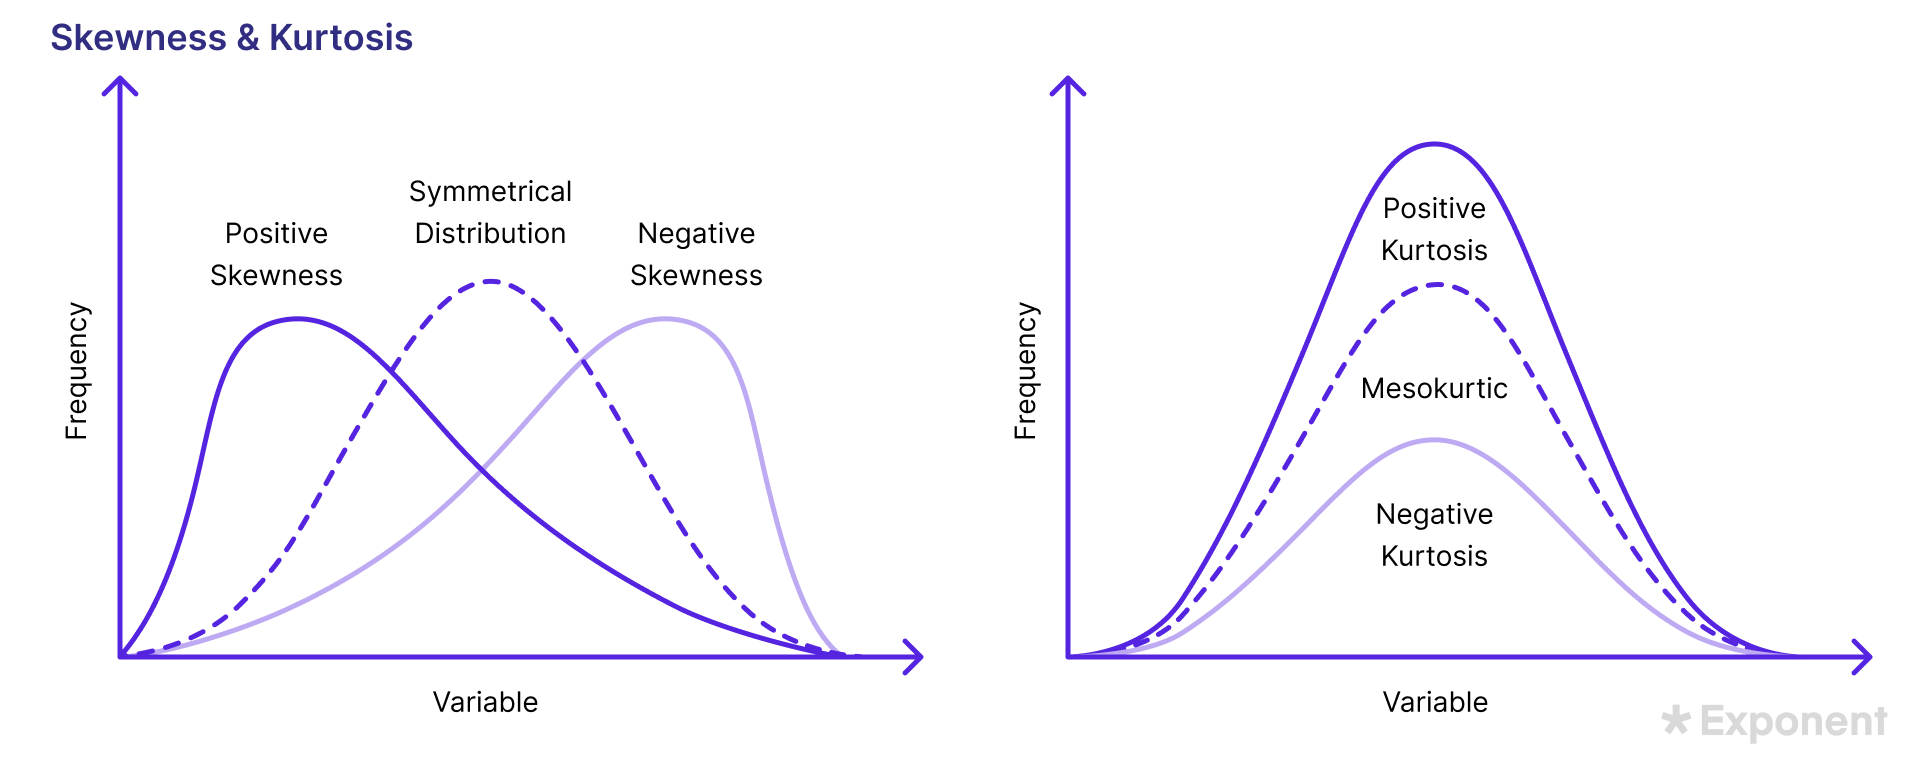

The **Jarque-Bera test** is a statistical test that checks whether a series is normally distributed.

The **Probability** row is the p-value of the Jarque-Bera test.

In [136]:
righe = ["Mean", "Median", "Maximum", "Minimum", "Std. Dev.","Skewness", "Kurtosis", "Jarque-Bera", "Probability", "Observations"]

colonne = {"EUROSTOXX50_ret": "EURO STOXX 50 return","BRENTOIL_ret": "BRENTOIL return","SR5Y": "EU 5-year Bond Yield","SR10Y": "EU 10-year Bond Yield",
           "SR30Y": "EU 30-year Bond Yield","EONIA_ESTR": "Overnight Rate","LOGM2REAL": "Log Real M2","EURO_ret": "Euro return"}

table = pd.DataFrame(index=righe)                                     # creo tabella vuota
for c in colonne:                                                     # ciclo sulle colonne
    s = dataset[c]
    jb = jarque_bera(s)
    table[colonne[c]] = [s.mean(),s.median(),s.max(),s.min(),s.std(),skew(s),kurtosis(s, fisher=False),jb.statistic,jb.pvalue,s.count()]

table = table.round(3)                                                # arrotondo a 3 cifre
display(table)                                                        # mostro tabella

,EURO STOXX 50 return,BRENTOIL return,EU 5-year Bond Yield,EU 10-year Bond Yield,EU 30-year Bond Yield,Overnight Rate,Log Real M2,Euro return
Mean,0.023,0.043,1.868,2.549,3.255,0.981,16.367,0.004
Median,0.043,0.030,2.431,3.093,3.579,0.253,16.358,0.005
Maximum,11.002,50.987,4.810,5.069,5.838,4.516,16.663,2.605
Minimum,-12.401,-47.465,-0.562,-0.264,0.521,-0.593,15.946,-2.915
Std. Dev.,1.303,2.570,1.477,1.473,1.316,1.589,0.194,0.319
Skewness,-0.123,0.652,-0.169,-0.412,-0.407,0.741,-0.267,-0.113
Kurtosis,11.293,65.911,1.629,1.728,1.939,2.041,2.093,8.628
Jarque-Bera,15799.065,908872.443,457.764,527.438,410.310,715.115,254.444,7281.255
Probability,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Observations,5509.000,5509.000,5509.000,5509.000,5509.000,5509.000,5509.000,5509.000


In [137]:
def plot_series(dataset, col, date_col="Date", title=None):                                  # simple plot of one series
    df = dataset.copy()                                                                       # copy dataframe
    df[date_col] = pd.to_datetime(df[date_col])                                              # convert dates
    df = df.sort_values(date_col)                                                             # sort by date

    plt.figure(figsize=(10, 4))                                                               # create figure
    plt.plot(df[date_col], df[col], lw=1.2)                                                   # plot series
    plt.title(title if title else col, fontsize=12, fontweight="bold")                       # set title
    plt.grid(True, alpha=0.3)                                                                 # light grid
    plt.tight_layout()
    plt.show()

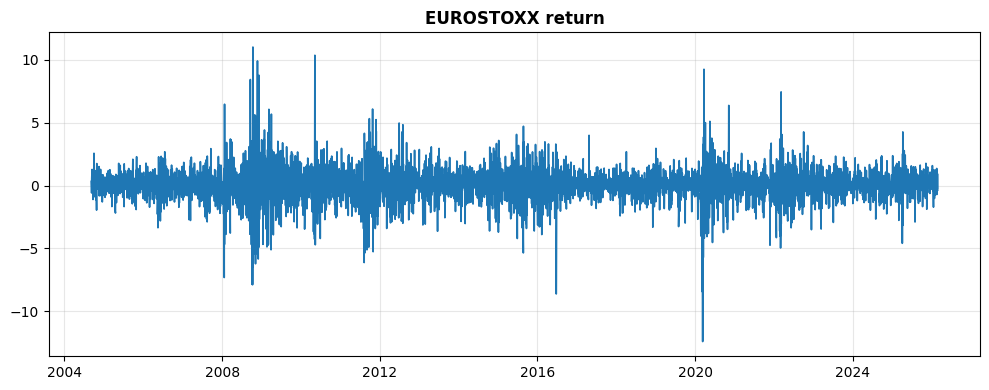

In [138]:
plot_series(dataset, "EUROSTOXX50_ret", title="EUROSTOXX return")

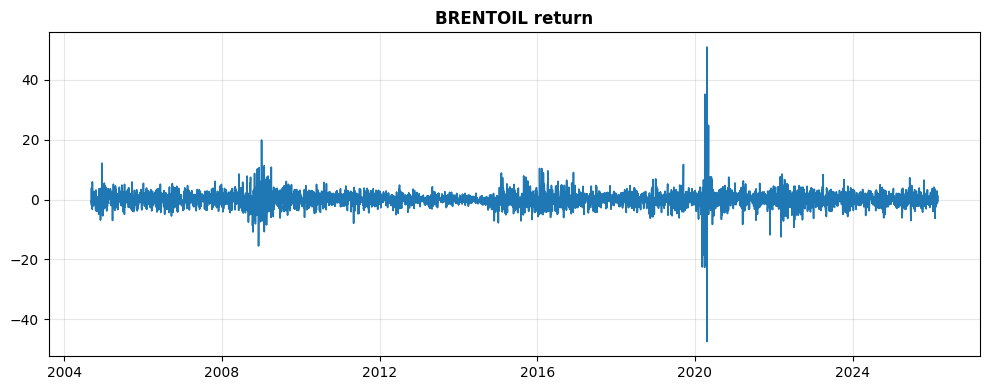

In [139]:
plot_series(dataset, "BRENTOIL_ret", title="BRENTOIL return")

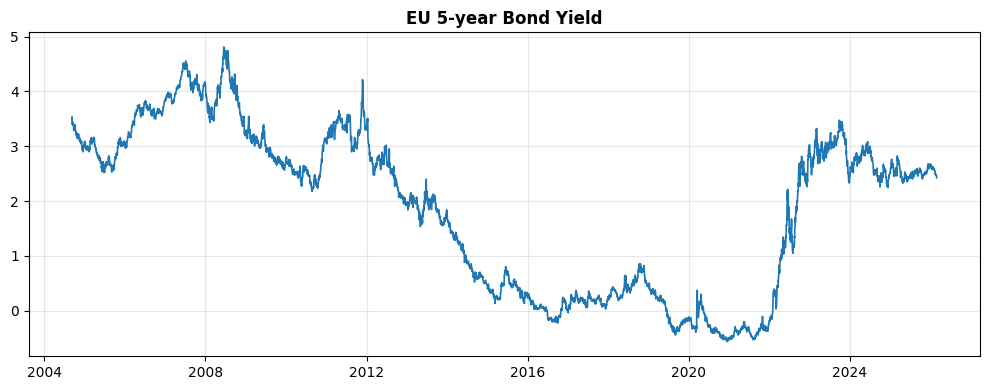

In [140]:
plot_series(dataset, "SR5Y", title="EU 5-year Bond Yield")

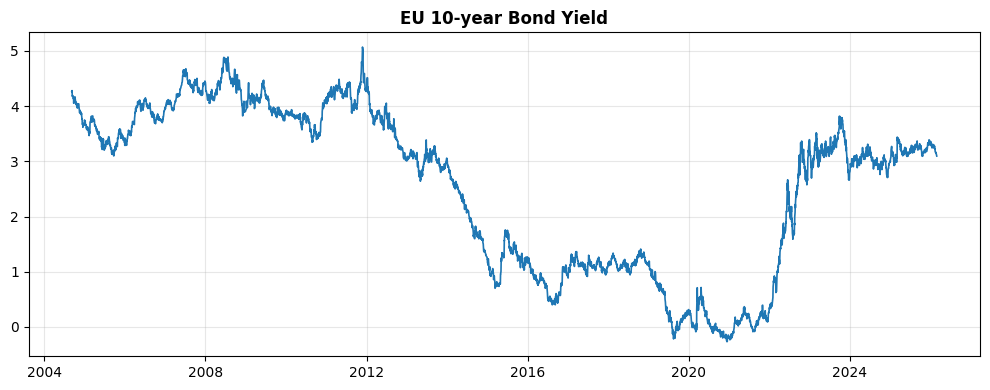

In [141]:
plot_series(dataset, "SR10Y", title="EU 10-year Bond Yield")

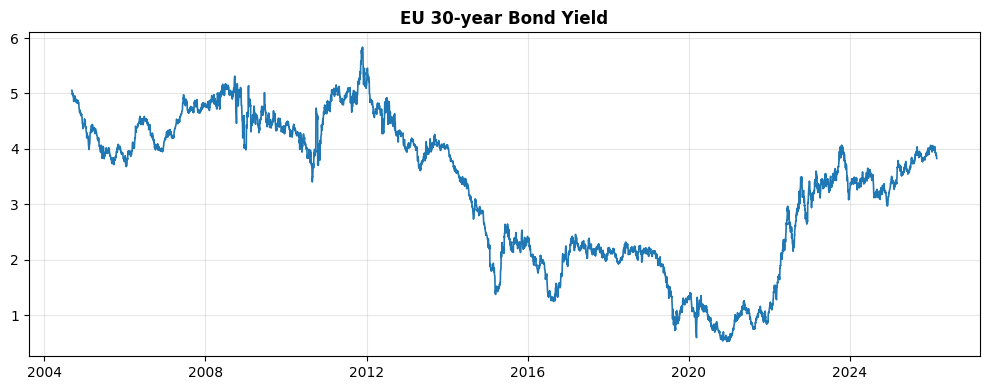

In [142]:
plot_series(dataset, "SR30Y", title="EU 30-year Bond Yield")

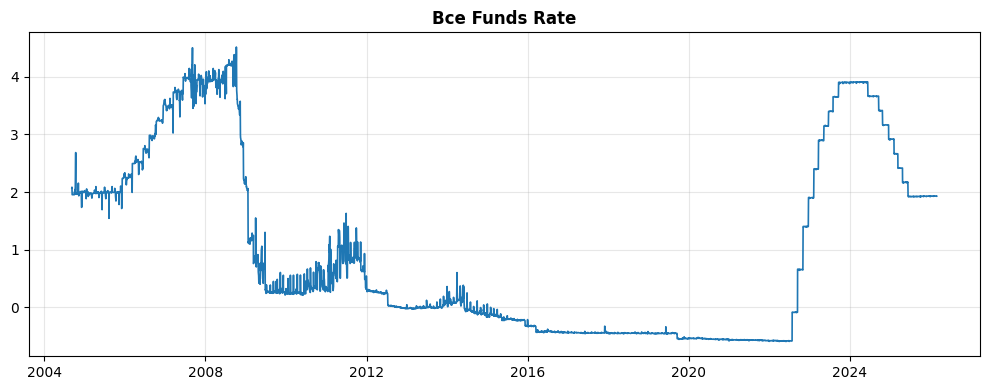

In [143]:
plot_series(dataset, "EONIA_ESTR", title="Bce Funds Rate")

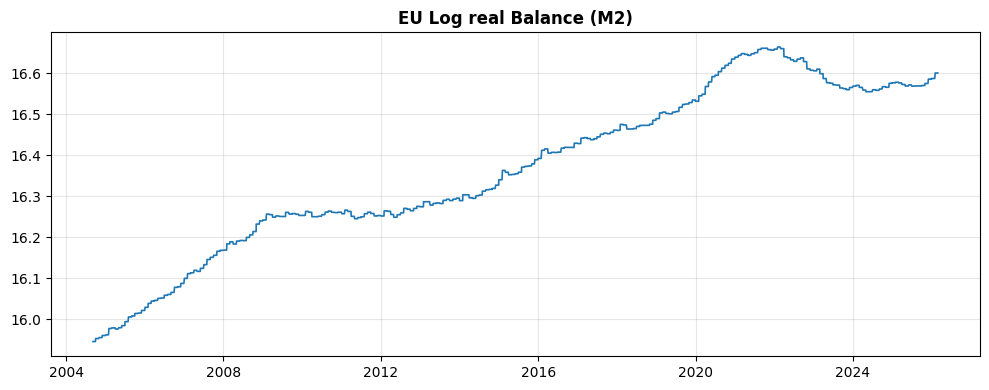

In [144]:
plot_series(dataset, "LOGM2REAL", title="EU Log real Balance (M2)")

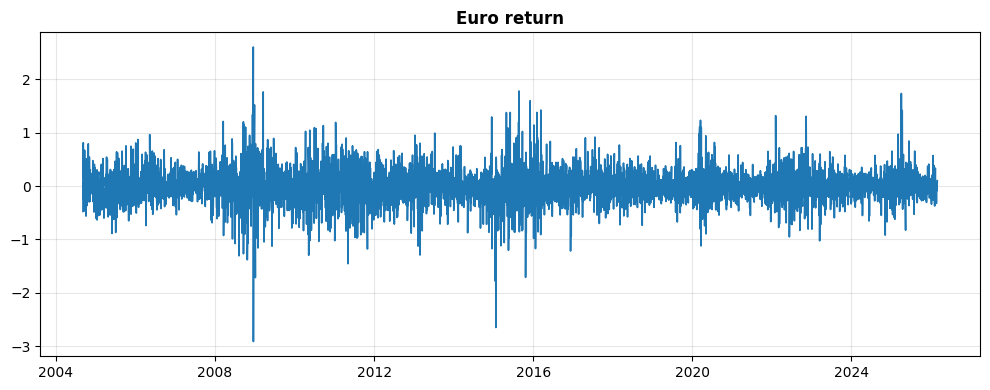

In [145]:
plot_series(dataset, "EURO_ret", title="Euro return")

# **Dataset Export**

Finally, the dataset is **exported in CSV format**, so that it can be used in the subsequent analyses.

In [146]:
dataset.to_csv("processedDataset/datasetEU.csv", index=False)